# 🛠️ Customer Churn Prediction: Preprocessing & Modeling
### *Playground Series S6E3*

---

## 📌 Project Objective
In this phase, we translate our **EDA** insights into a structured format for Machine Learning. Our focus is to clean the data, encode categorical variables, and train a baseline model to predict customer churn accurately using the ROC-AUC metric.

---

## 🗺️ Notebook Structure
1. **Setup & Environment** - Importing libraries and configurations.
2. **Data Loading** - Importing the train and test datasets.
3. **Feature Engineering** - Removing unnecessary columns and handling categorical data.
4. **Baseline Modeling** - Splitting data and training an initial classifier.
5. **Initial Evaluation** - Measuring performance via validation set.

---


## 1. Setup & Environment
We import essential libraries for data manipulation, preprocessing, and modeling. We will use **XGBoost** as our baseline model due to its efficiency with tabular data.

In [7]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 4.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 4.4 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.0 MB 4.4 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 4.1 MB/s eta 0:00:02
   ----------------- ---------------------- 3.4/8.0 MB 3.8 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.0 MB 3.8 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.0 MB 3.6 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.0 MB 3.5 MB/s eta 0:00:01
   ------------------------------ --------- 6.0/8.0 MB 3.5 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.0 MB 3.3 MB/s eta 0:00:01
   ----------------------------------- ---- 7.1/8.0 MB 3.2 MB/s eta 0:00:01
   -----------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 5.6 MB/s eta 0:00:18
    --------------------------------------- 1.3/101.7 MB 4.3 MB/s eta 0:00:24
    --------------------------------------- 2.1/101.7 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 2.4/101.7 MB 2.9 MB/s eta 0:00:35
   - -------------------------------------- 2.9/101.7 MB 2.5 MB/s eta 0:00:40
   - -------------------------------------- 4.2/101.7 MB 3.0 MB/s eta 0:00:33
   - -------------------------------------- 5.0/101.7 MB 3.2 MB/s eta 0:00:31
   -- ------------------------------------- 5.2/101.7 MB 3.3 MB/s eta 0:00:30
   -- ------------------------------------- 5.8/101.7 MB 2.9 MB/s eta 0:00:33
   -- ------------------------------------- 6.6/101.7 MB 3.0 MB/s eta 0:00:32
   -- ------------------------------------- 7.1/101.7 MB 2.9 MB/s eta 0:00:33



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
from xgboost import XGBClassifier

# Visualization settings
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings('ignore')

print("Setup Complete.")


Setup Complete.


## 2. Load Data
In this section, we import the raw training and testing datasets. The training set will be used for model building, while the test set will be used for final predictions. We ensure that both datasets are loaded correctly by checking their shapes.

In [12]:
# Defining file paths
TRAIN_PATH = "../Dataset/train.csv"
TEST_PATH  = "../Dataset/test.csv"

# Loading datasets
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Data loaded successfully.")


Data loaded successfully.


In [13]:
# Checking the size of the datasets
print(f"Training Rows: {train.shape[0]}, Columns: {train.shape[1]}")
print(f"Testing Rows: {test.shape[0]}, Columns: {test.shape[1]}")

# Quick view of the data structure
train.head()

Training Rows: 594194, Columns: 21
Testing Rows: 254655, Columns: 20


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


## 3. Preprocessing & Feature Engineering
Following our EDA, we now prepare the data for machine learning. We will drop non-influential features like `id` and `gender`. Then, we apply **Label Encoding** to all categorical text columns and our target variable, converting everything into numerical values.

In [14]:
# Dropping features identified as non-useful during EDA
train = train.drop(columns=['id', 'gender'])
test = test.drop(columns=['id', 'gender'])

print(f"Features after dropping: {train.shape[1]}")


Features after dropping: 19


In [15]:
# Identifying columns with string (object) data types for encoding
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

# Removing the target column 'Churn' from the list of features to encode
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

print(f"Categorical Features to Encode: {cat_cols}")


Categorical Features to Encode: ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [16]:
# Applying LabelEncoder to categorical features
le = LabelEncoder()

for col in cat_cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

print("Feature encoding complete.")


Feature encoding complete.


In [17]:
# Encoding the target variable 'Churn' (No=0, Yes=1)
train['Churn'] = le.fit_transform(train['Churn'])

# Final check of the preprocessed data
train.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,1,1,29,1,0,0,2,0,2,2,0,0,1,1,3,60.10,1653.85,0
1,0,1,1,58,1,0,0,2,2,0,2,2,0,2,0,1,69.50,3778.20,0
2,0,1,0,58,1,2,1,0,2,0,0,2,2,0,1,2,100.40,5841.35,0
3,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,69.70,70.70,1
4,0,0,0,1,1,0,1,0,0,0,0,0,0,0,1,2,70.45,70.45,1


## 4. Baseline Modeling
In this section, we prepare our data for training. We will split the dataset into features (X) and target (y), followed by a train-validation split (80/20). We start with **XGBoost** as our baseline model to establish a performance benchmark.


In [18]:
# Separating features and the target variable
X = train.drop(columns=['Churn'])
y = train['Churn']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (594194, 18)
Target (y) shape: (594194,)


In [19]:
# Splitting the data into Training and Validation sets (80% Train, 20% Validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")


Training set: (475355, 18)
Validation set: (118839, 18)


In [20]:
# Initializing the XGBoost model
# tree_method='hist' helps speed up training on large datasets
model_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    tree_method='hist', # Fast histogram optimized method
    enable_categorical=False
)

# Training the model
print("Training the baseline model... Please wait.")
model_xgb.fit(X_train, y_train)

print("Training Complete!")


Training the baseline model... Please wait.
Training Complete!


In [21]:
# Making predictions on the validation set
# We use predict_proba to get probabilities for the ROC-AUC score
y_pred_proba = model_xgb.predict_proba(X_val)[:, 1]

# Calculating ROC-AUC Score
auc_score = roc_auc_score(y_val, y_pred_proba)

print(f"Baseline XGBoost ROC-AUC Score: {auc_score:.5f}")


Baseline XGBoost ROC-AUC Score: 0.91648


## 5. Feature Importance & Evaluation
In this final section of the preprocessing and modeling phase, we visualize the feature importance to understand which variables drive the model's decisions. This helps us validate our EDA findings and ensures the model is focusing on relevant customer behaviors.


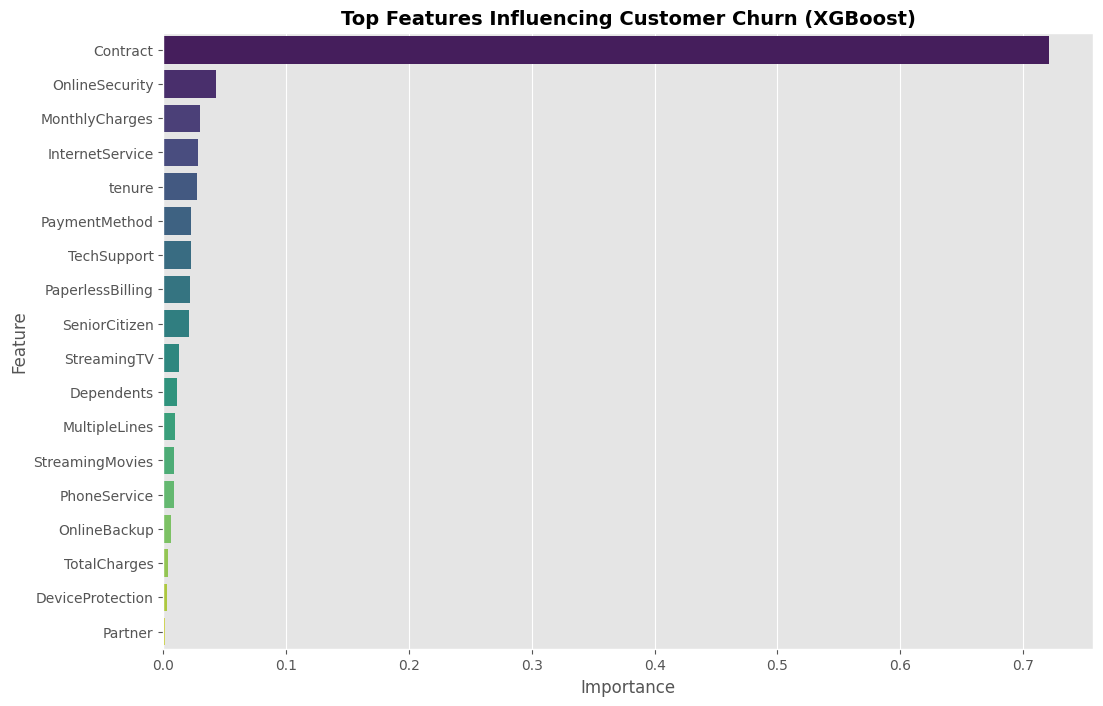

In [22]:
# Extracting feature importances
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Top Features Influencing Customer Churn (XGBoost)', fontsize=14, fontweight='bold')
plt.show()


## 6. Summary & Conclusion 📝

In this phase, we moved from data understanding to data execution. We successfully transformed the raw Telco customer data into a machine-learning-ready format and established a high-performing baseline model.

### 🔑 Key Achievements:
1. **Efficient Preprocessing:** By dropping non-influential features (`id`, `gender`) and applying `Label Encoding`, we reduced noise and dimensionality, resulting in a cleaner dataset.
2. **Robust Performance:** Our baseline **XGBoost** model achieved a **ROC-AUC score of 0.91648** on the validation set. This indicates a high degree of confidence in the model's ability to distinguish between churners and non-churners.
3. **Validating Insights:** The **Feature Importance** analysis confirms that **Contract Type** is the single most significant predictor of churn, followed by security services and billing amounts. This perfectly aligns with our findings from the EDA phase.

---

## 🏁 Phase 2 Completion
The model is now stable and performing well. We have a solid foundation to move towards the final stage of the project.

**Next Steps in Notebook 03:**
*   Generating final predictions on the unseen test dataset.
*   Formatting results into the required `submission.csv` format for Kaggle.
*   Brief exploration of hyperparameter tuning to squeeze out any remaining performance gains.
